# CS 3110/5110: Data Privacy
## In-Class Exercise #3, week of 9/21/2026

In [13]:
# Load the data and libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

adult = pd.read_csv('https://github.com/jnear/cs3110-data-privacy/raw/main/homework/adult_with_pii.csv')

## Question 5

Consider the program below.

In [14]:
counting_query = lambda: 1

# I made placeholder epsilons, they were missing
epsilon1 = 0.1
epsilon2 = 0.15
result_1 = counting_query() + np.random.laplace(loc=0, scale=1/epsilon1)
result_2 = counting_query() + np.random.laplace(loc=0, scale=1/epsilon2)
result_3 = counting_query() + np.random.laplace(loc=0, scale=1/epsilon1)

print(result_1, result_2, result_3)

-8.34391570579226 -40.402278483138524 6.57088644810504


Write a function `total_epsilon` that returns the total privacy cost for this program.

In [15]:
def total_epsilon():
    # YOUR CODE HERE
    return epsilon1 + epsilon2 + epsilon1

In [16]:
epsilon = 0.1
results = [len(adult[adult['Age'] > 65]) + np.random.laplace(loc=0, scale=1/epsilon) for _ in range(1000)]

#priacy cost of 0.1 * 1000

## Question 1

Implement the Laplace mechanism below.

In [17]:
def laplace_mech(v, sensitivity, epsilon):
    return v + np.random.laplace(loc=0, scale=sensitivity/epsilon)

In [18]:
# TEST CASE for question 1
dist1 = [laplace_mech(50, 1, 1.0) for _ in range(200)]
dist2 = [np.random.laplace(loc=50, scale=1) for _ in range(200)]

assert stats.wasserstein_distance(dist1, dist2) < 1

## Question 2

# Write a diffly private func to return num people > 30



In [19]:
def people_over_30_dp():
    return len(adult[adult['Age'] > 30])



In [20]:
# TEST CASE for question 2
dist1 = [np.random.laplace(loc=21989, scale=1.0) for _ in range(200)]
dist2 = [people_over_30_dp() for _ in range(200)]

assert stats.wasserstein_distance(dist1, dist2) < 1

## Question 3

Consider the following definition of a differencing attack (without differential privacy).

In [21]:
def differencing_attack():
    q1 = adult['Age'].sum()
    q2 = adult[adult['Name'] != 'Karrie Trusslove']['Age'].sum()

    return q1 - q2

print('Differencing attack result:', differencing_attack())

Differencing attack result: 39


Implement a function `dp_differencing_attack` that performs the same attack, but attempts to satisfy differential privacy using the Laplace mechanism. Use the parameters `sensitivity=1` and `epsilon=1.0`.

In [22]:
def dp_differencing_attack():
    q1 = adult['Age'].sum()
    q2 = adult[adult['Name'] != 'Karrie Trusslove']['Age'].sum()

    # Bug: sensitivity is wrong
    noisy_q1 = laplace_mech(q1, sensitivity=1, epsilon=1) # used to be 1
    noisy_q2 = laplace_mech(q2, sensitivity=1, epsilon=1) # used to be 1
    # Adding noise twice, we get total cost of 2, not 1 we get in question, so ep should be 0.5

    return noisy_q1 - noisy_q2

print('DP Differencing attack result:', dp_differencing_attack())

DP Differencing attack result: 39.51594177237712


In [23]:
# TEST CASE for question 1
dp_results = [dp_differencing_attack() for _ in range(100)]
spec = [np.random.laplace(loc=39, scale=1) for _ in range(100)]
assert stats.wasserstein_distance(dp_results, spec) < 2

## Question 4

What is the *sensitivity* of the `differencing_attack` query defined above, and why?

The sensitivity of the sum in general is unbounded. In this case, we can ssume ages are bounded by 120, so 120.

## Question 5

Implement a corrected version of `dp_differencing_attack` that uses the correct sensitivity and thus correctly satisfies differential privacy.

In [24]:
def dp_differencing_attack_corrected():
    q1 = adult['Age'].sum()
    q2 = adult[adult['Name'] != 'Karrie Trusslove']['Age'].sum()
    
    noisy_q1 = laplace_mech(q1, sensitivity=1, epsilon=0.5) # used to be 1
    noisy_q2 = laplace_mech(q2, sensitivity=1, epsilon=0.5) # used to be 1# YOUR CODE HERE
    return q1 - q2
print('DP Differencing attack result:', dp_differencing_attack_corrected())

DP Differencing attack result: 39


In [25]:
# TEST CASE for question 3
dp_results = [dp_differencing_attack_corrected() for _ in range(100)]
spec = [np.random.laplace(loc=39, scale=125/2.0) for _ in range(100)]
assert stats.wasserstein_distance(dp_results, spec) < 200
assert stats.wasserstein_distance(dp_results, spec) > 50

## Question 6

Write a function `dp_mean_age` that calculates the mean age of members of the dataset.

In [ ]:
def mean_age():
    # sum / count
    return adult['Age'].mean()

mean_age()

In [55]:
def dp_mean_age(epsilon):
    noisy_sum = laplace_mech(adult['Age'].sum(), sensitivity=120, epsilon=epsilon/2)
    noisy_count = laplace_mech(len(adult), sensitivity=1, epsilon=epsilon/2)
    return noisy_sum / noisy_count
    

In [56]:
# TEST CASE for question 1
results = [dp_mean_age(1) for _ in range(100)]
assert np.abs(np.mean(results) - mean_age()) < 0.1

## Question 7

Write a function `dp_age_sum_clipping` that uses clipping to bound the sensitivity of the sum of ages.

In [49]:
def dp_age_sum_clipping(epsilon, b):
    clipped_ages = adult['Age'].clip(lower=0, upper=b)
    return laplace_mech(clipped_ages.sum(), sensitivity=b, epsilon=epsilon  )

dp_age_sum_clipping(1.0, 100)

np.float64(1256454.6141604527)

In [50]:
# TEST CASE for question 2
results = [dp_age_sum_clipping(1.0, 100) for _ in range(10)]
assert np.abs(np.mean(results) - adult['Age'].sum()) < 100

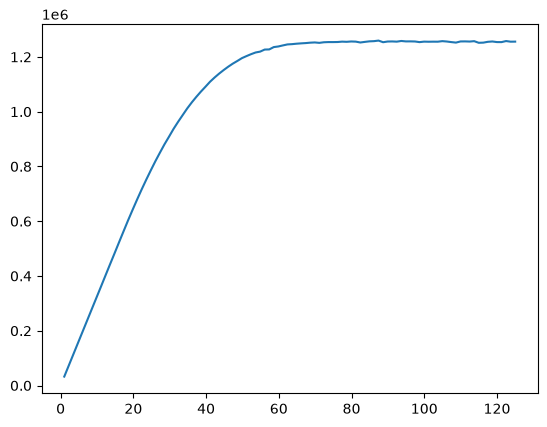

In [51]:
bs = np.linspace(1, 125, 100)
results = [dp_age_sum_clipping(0.1, b) for b in bs]
plt.plot(bs, results);

#baseline = [adult['Age'].sum() for b in bs]
#plt.plot(bs, baseline);